<a href="https://colab.research.google.com/github/piughosh2/sentiment_analysis/blob/main/kaggle_sentiment_analysis0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print ("hello world")

hello world


In [ ]:
print ("hello piu")

hello piu


In [ ]:
! pip install kaggle

In [ ]:
#configuring the path of kaggle.json file
! mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

importing dataset

In [ ]:
#api to fetch the dataset from kaggle
!kaggle datasets download -d kazanova/sentiment140


Dataset URL: https://www.kaggle.com/datasets/kazanova/sentiment140
License(s): other
  0% 0.00/80.9M [00:00<?, ?B/s]
100% 80.9M/80.9M [00:00<00:00, 1.65GB/s]


In [ ]:
# extracting the compressed dataset

from zipfile import ZipFile
dataset ='/content/sentiment140.zip'

with ZipFile(dataset,'r') as zip :
  zip.extractall()
  print("the dataset is extracted")

the dataset is extracted


importing the dependencies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
import nltk
nltk.download ("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
#printing stopwords
print(stopwords.words("english"))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

data processing


In [ ]:
#loading the data from csv file to pandas dataframe
twitter_data = pd.read_csv("/content/training.1600000.processed.noemoticon.csv",encoding = "ISO-8859-1")

In [ ]:
#checking the number of rws and columns
twitter_data.shape

(1599999, 6)

In [ ]:
#printing first 5 rows of the dataframe
twitter_data.head()

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [ ]:
# naming the columns
column_names=['target','id','date','flag','user','text']
twitter_data = pd.read_csv("/content/training.1600000.processed.noemoticon.csv",names=column_names, encoding = "ISO-8859-1")

In [ ]:
twitter_data.shape

(1600000, 6)

In [ ]:
#printing first 5 rows of the dataframe
twitter_data.head()

,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [ ]:
#couting the number of missing values in the dataset
twitter_data.isnull().sum()

,0
target,0
id,0
date,0
flag,0
user,0
text,0


In [ ]:
#checking the distribution of target column
twitter_data['target'].value_counts()

,count
target,
0,800000
4,800000


<Axes: xlabel='target'>

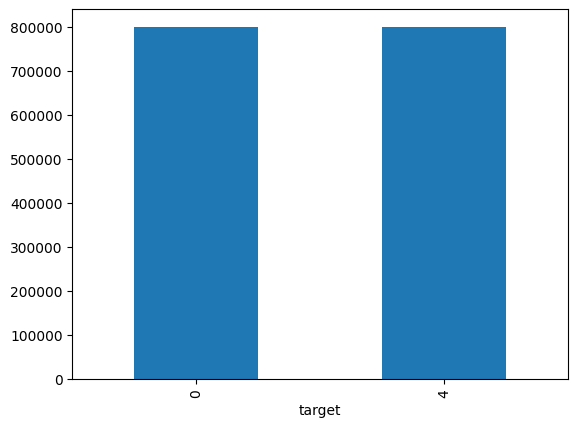

In [ ]:
twitter_data['target'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'target distribution')

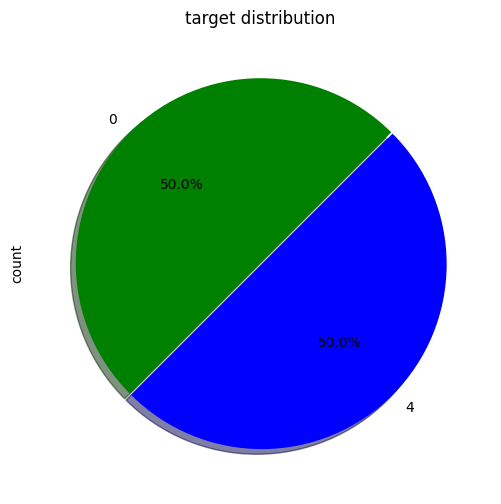

In [ ]:
plt.figure(figsize=(10,6))
colors = ['green', 'blue']
twitter_data['target'].value_counts().plot(kind='pie', autopct='%.1f%%',shadow = True,colors = colors,startangle = 45,
                 explode=(0, 0.01))
plt.title('target distribution')

convert the target 4 to 1

In [ ]:
twitter_data.replace({'target':{4:1}},inplace=True)

In [ ]:
#checking the distribution of target column
twitter_data['target'].value_counts()

,count
target,
0,800000
1,800000


Text(0.5, 1.0, 'target distribution')

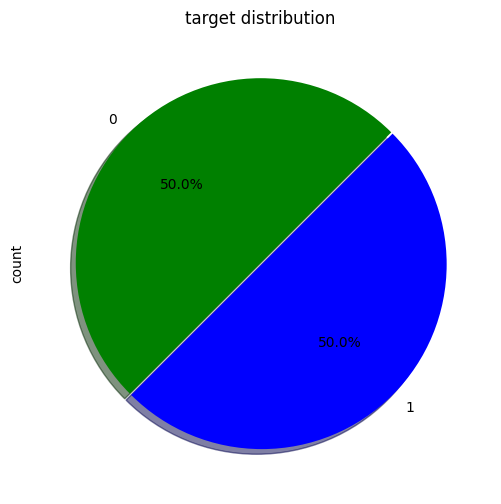

In [ ]:
plt.figure(figsize=(10,6))
colors = ['green', 'blue']
twitter_data['target'].value_counts().plot(kind='pie', autopct='%.1f%%',shadow = True,colors = colors,startangle = 45,
                 explode=(0, 0.01))
plt.title('target distribution')

<Axes: xlabel='target'>

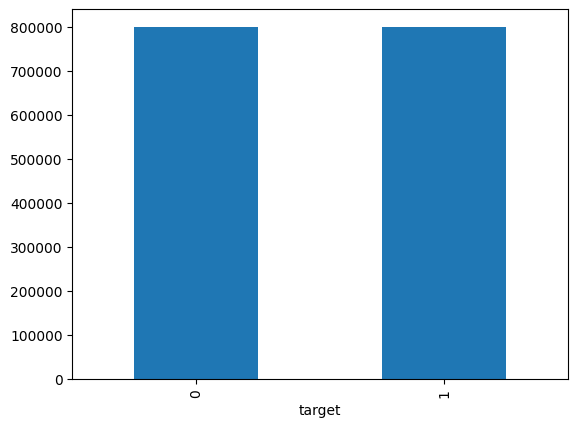

In [ ]:
twitter_data['target'].value_counts().plot(kind='bar')

In [ ]:
#0 means negative tweet and 1 means positive tweet
#STEMMING : it is a process of reducing a word to its root word like loving to love
port_stem=PorterStemmer()

In [ ]:
def stemming(content):

  stemmed_content = re.sub('[^a-zA-Z]',' ',content)
  stemmed_content= stemmed_content.lower()
  stemmed_content=stemmed_content.split()
  stemmed_content=[port_stem.stem(word) for word in stemmed_content if not word in stopwords.words("english")]
  stemmed_content = ''.join(stemmed_content)

  return stemmed_content

In [ ]:
twitter_data['stemmed_content']=twitter_data['text'].apply(stemming)

In [ ]:
twitter_data.head()

,target,id,date,flag,user,text,stemmed_content
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",switchfoothttptwitpiccomzlawwwbummershouldagot...
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,upsetupdatfacebooktextmightcriresultschooltoda...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,kenichandivemanitimeballmanagsaverestgobound
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,wholebodifeelitchilikefire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",nationwideclassbehavmadsee


In [ ]:
print(twitter_data['stemmed_content'])

0          switchfoothttptwitpiccomzlawwwbummershouldagot...
1          upsetupdatfacebooktextmightcriresultschooltoda...
2               kenichandivemanitimeballmanagsaverestgobound
3                                 wholebodifeelitchilikefire
4                                 nationwideclassbehavmadsee
                                 ...                        
1599995                               wokeschoolbestfeelever
1599996      thewdbcomcoolhearoldwaltinterviewhttpblipfmbmta
1599997                             readimojomakeovaskdetail
1599998           happithbirthdaybooallltimetupacamarushakur
1599999    happicharitytuesdaythenspccsparkscharspeakinguphh
Name: stemmed_content, Length: 1600000, dtype: object


In [ ]:
print(twitter_data['target'])

0          0
1          0
2          0
3          0
4          0
          ..
1599995    1
1599996    1
1599997    1
1599998    1
1599999    1
Name: target, Length: 1600000, dtype: int64


In [ ]:
# separating the data and label
X = twitter_data['stemmed_content'].values
Y =twitter_data['target'].values

In [ ]:
print(X)

['switchfoothttptwitpiccomzlawwwbummershouldagotdavidcarrthirdday'
 'upsetupdatfacebooktextmightcriresultschooltodayalsoblah'
 'kenichandivemanitimeballmanagsaverestgobound' ...
 'readimojomakeovaskdetail' 'happithbirthdaybooallltimetupacamarushakur'
 'happicharitytuesdaythenspccsparkscharspeakinguphh']


In [ ]:
print(Y)

[0 0 0 ... 1 1 1]


data split in to training data and test data

In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=2)


In [ ]:
print(X.shape,X_train.shape,X_test.shape)

(1600000,) (1280000,) (320000,)


In [ ]:
print(X_train)

['watchsawivdrinklilwine' 'hatermagazin'
 'eventhoughfavouritdrinkthinkvodkacokewipemindtimethinkimgonnafindnewdrink'
 ... 'eagermondayafternoon'
 'hopeeveryonmothergreatdaywaithearguystoretomorrow'
 'lovewakefolgerbadvoicdeeper']


In [ ]:
print(X_test)

['mmangenfinemuchtimechattwitterhubbibacksummeramptenddominfreetime'
 'ahmayshowwruthkimampgeoffreysanhueza' 'ishataramaybbayareathangdammit'
 ... 'destinineverthelesshooraymemberwondersafetrip' 'feelwell'
 'supersandrothank']


In [ ]:
#converting the textual data to neumerical data

vectorizer = TfidfVectorizer()

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [ ]:
print(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1279572 stored elements and shape (1280000, 1239526)>
  Coords	Values
  (0, 1163354)	1.0
  (1, 435884)	1.0
  (2, 283352)	1.0
  (3, 1062770)	1.0
  (4, 1091794)	1.0
  (5, 197786)	1.0
  (6, 577996)	1.0
  (7, 114435)	1.0
  (8, 782552)	1.0
  (9, 482000)	1.0
  (10, 280992)	1.0
  (11, 898312)	1.0
  (12, 1137048)	1.0
  (13, 386454)	1.0
  (14, 992231)	1.0
  (15, 1236032)	1.0
  (16, 23878)	1.0
  (17, 330941)	1.0
  (18, 433866)	1.0
  (19, 175299)	1.0
  (20, 890756)	1.0
  (21, 456873)	1.0
  (22, 327755)	1.0
  (23, 219744)	1.0
  (24, 1238202)	1.0
  :	:
  (1279975, 96044)	1.0
  (1279976, 1074177)	1.0
  (1279977, 890012)	1.0
  (1279978, 949326)	1.0
  (1279979, 744769)	1.0
  (1279980, 800670)	1.0
  (1279981, 530027)	1.0
  (1279982, 905736)	1.0
  (1279983, 480531)	1.0
  (1279984, 72766)	1.0
  (1279985, 57198)	1.0
  (1279986, 979289)	1.0
  (1279987, 728143)	1.0
  (1279988, 1198114)	1.0
  (1279989, 436984)	1.0
  (1279990, 840415)	1.0
  (127999

In [ ]:
print(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 13076 stored elements and shape (320000, 1239526)>
  Coords	Values
  (22, 142218)	1.0
  (36, 110203)	1.0
  (55, 1217927)	1.0
  (104, 1106350)	1.0
  (211, 638230)	1.0
  (216, 325572)	1.0
  (277, 878817)	1.0
  (287, 1147489)	1.0
  (316, 602153)	1.0
  (317, 197811)	1.0
  (326, 841257)	1.0
  (343, 705383)	1.0
  (356, 969648)	1.0
  (405, 335231)	1.0
  (411, 702251)	1.0
  (412, 597658)	1.0
  (439, 387397)	1.0
  (503, 864270)	1.0
  (534, 1038977)	1.0
  (545, 1149970)	1.0
  (575, 499192)	1.0
  (576, 1201924)	1.0
  (585, 1105943)	1.0
  (586, 738701)	1.0
  (597, 1149673)	1.0
  :	:
  (319546, 707289)	1.0
  (319550, 983292)	1.0
  (319573, 1017879)	1.0
  (319595, 439456)	1.0
  (319630, 484111)	1.0
  (319632, 372983)	1.0
  (319640, 385578)	1.0
  (319649, 1153567)	1.0
  (319668, 350853)	1.0
  (319673, 175909)	1.0
  (319679, 429520)	1.0
  (319687, 1168138)	1.0
  (319700, 888036)	1.0
  (319712, 248499)	1.0
  (319716, 1171828)	1.0
  (319752, 

trainning the  ml model

In [ ]:
model = LogisticRegression(max_iter=1000)

In [ ]:
model.fit(X_train,Y_train)

LogisticRegression(max_iter=1000)

model evaluation

accuracy score

In [ ]:
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(Y_train,X_train_prediction)

In [ ]:
print("accuracy score on the training data : " ,training_data_accuracy)

accuracy score on the training data :  0.99614140625


In [ ]:
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(Y_test,X_test_prediction)

In [ ]:
print("accuracy score on the test data : " ,test_data_accuracy)

accuracy score on the test data :  0.519303125


saving the trained model

In [ ]:
import pickle

In [ ]:
filename='trained_model.sav'
pickle.dump(model,open(filename,'wb'))

using the saved model for future prediction

In [ ]:
#loading to saved model

loaded_model = pickle.load(open('/content/trained_model.sav','rb'))

In [ ]:
X_new = X_test[200]
print (Y_test[200])

prediction = loaded_model.predict(X_new)
print(prediction)

if (prediction[0]==0):
     print("negative tweet")
else:
      print ("positive tweet")

1
[1]
positive tweet
